Usando o exemplo 499

In [1]:
%pip install pandas numpy seaborn xgboost
%pip install nltk
%pip install lime
%pip install shap

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.2.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.2.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.2.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.2.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np
import re
import seaborn as sns
import matplotlib.pyplot as plt
import shap

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score
from sklearn.preprocessing import LabelEncoder
from lime import lime_text

from xgboost import XGBClassifier
from sklearn.feature_extraction.text import TfidfVectorizer

c:\Users\LUIRYS SILVA\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
df = pd.read_csv('../news_clean_onlly.csv')

In [4]:
df.head()

,Unnamed: 0,title,subject,date,Label,clean_text,label_number,char_count,word_count,avg_word_length
0,0,Donald Trump Sends Out Embarrassing New Year’...,News,"December 31, 2017",Fake,donald trump just couldn t wish all americans ...,0,2620,474,5.527426
1,1,Drunk Bragging Trump Staffer Started Russian ...,News,"December 31, 2017",Fake,house intelligence committee chairman devin nu...,0,1850,304,6.085526
2,2,Sheriff David Clarke Becomes An Internet Joke...,News,"December 30, 2017",Fake,on friday it was revealed that former milwauke...,0,3298,564,5.847518
3,3,Trump Is So Obsessed He Even Has Obama’s Name...,News,"December 29, 2017",Fake,on christmas day donald trump announced that h...,0,2462,423,5.820331
4,4,Pope Francis Just Called Out Donald Trump Dur...,News,"December 25, 2017",Fake,pope francis used his annual christmas day mes...,0,2292,420,5.457143


In [5]:
df.shape

(38516, 10)

<Axes: xlabel='Label', ylabel='count'>

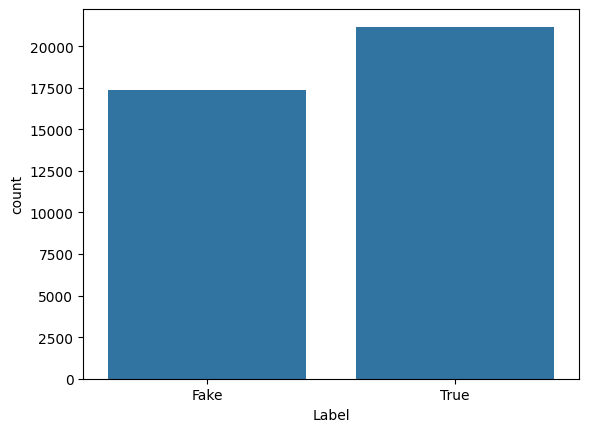

In [7]:
sns.countplot(x='Label', data = df)

**Pré-Processamento**

In [8]:
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
import re

# Baixar pacotes necessários do NLTK
nltk.download("stopwords")
nltk.download("punkt")
nltk.download("wordnet")
nltk.download('punkt_tab') # Download the 'punkt_tab' resource

[nltk_data] Downloading package stopwords to C:\Users\LUIRYS
[nltk_data]     SILVA\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to C:\Users\LUIRYS
[nltk_data]     SILVA\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to C:\Users\LUIRYS
[nltk_data]     SILVA\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt_tab to C:\Users\LUIRYS
[nltk_data]     SILVA\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [9]:
def preprocess_text(text):
    # Converter para minúsculas
    text = text.lower()

    # Remover caracteres especiais e números
    text = re.sub(r"[^a-zA-Z\s]", "", text)

    # Tokenização (dividir em palavras)
    tokens = word_tokenize(text)

    # Remover stopwords
    stop_words = set(stopwords.words("english"))
    tokens = [word for word in tokens if word not in stop_words]

    # Lematização (reduzir palavras à sua forma base)
    lemmatizer = WordNetLemmatizer()
    tokens = [lemmatizer.lemmatize(word) for word in tokens]

    # Juntar as palavras processadas de volta em uma string
    return " ".join(tokens)

In [10]:
df["clean_text"] = df["title"].apply(preprocess_text)

In [11]:
df.head(5)

,Unnamed: 0,title,subject,date,Label,clean_text,label_number,char_count,word_count,avg_word_length
0,0,Donald Trump Sends Out Embarrassing New Year’...,News,"December 31, 2017",Fake,donald trump sends embarrassing new year eve m...,0,2620,474,5.527426
1,1,Drunk Bragging Trump Staffer Started Russian ...,News,"December 31, 2017",Fake,drunk bragging trump staffer started russian c...,0,1850,304,6.085526
2,2,Sheriff David Clarke Becomes An Internet Joke...,News,"December 30, 2017",Fake,sheriff david clarke becomes internet joke thr...,0,3298,564,5.847518
3,3,Trump Is So Obsessed He Even Has Obama’s Name...,News,"December 29, 2017",Fake,trump obsessed even obamas name coded website ...,0,2462,423,5.820331
4,4,Pope Francis Just Called Out Donald Trump Dur...,News,"December 25, 2017",Fake,pope francis called donald trump christmas speech,0,2292,420,5.457143


<Axes: xlabel='Label', ylabel='count'>

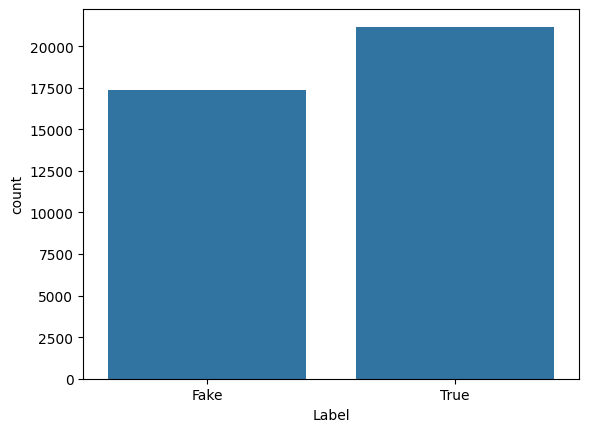

In [12]:
sns.countplot(x="Label", data=df) # validando se mudou as classes

In [14]:
le = LabelEncoder()
df['label_encoded'] = le.fit_transform(df['Label'])

In [15]:
X = df['clean_text']
y = df['label_encoded']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
#, stratify=y

In [16]:
tfidf = TfidfVectorizer(
    max_features=5000,
    stop_words=None
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

**XGBoost**

In [17]:
model = XGBClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    tree_method='hist',
    eval_metric='logloss',
    importance_type='gain',
    random_state=42,
    n_jobs=-1
)

In [18]:
# Mesma validação do Keras: validation_split=0.1 usa os últimos 10% do treino
val_size = int(0.1 * X_train_tfidf.shape[0])

X_tr, X_val = X_train_tfidf[:-val_size], X_train_tfidf[-val_size:]
y_tr, y_val = y_train.iloc[:-val_size], y_train.iloc[-val_size:]

model.fit(
    X_tr, y_tr,
    eval_set=[(X_tr, y_tr), (X_val, y_val)],
    verbose=20
)

[0]	validation_0-logloss:0.66592	validation_1-logloss:0.67891
[20]	validation_0-logloss:0.43619	validation_1-logloss:0.64398
[40]	validation_0-logloss:0.38339	validation_1-logloss:0.62965
[60]	validation_0-logloss:0.35342	validation_1-logloss:0.61526
[80]	validation_0-logloss:0.33091	validation_1-logloss:0.60381
[100]	validation_0-logloss:0.31315	validation_1-logloss:0.59366
[120]	validation_0-logloss:0.29885	validation_1-logloss:0.58481
[140]	validation_0-logloss:0.28646	validation_1-logloss:0.57558
[160]	validation_0-logloss:0.27587	validation_1-logloss:0.56890
[180]	validation_0-logloss:0.26677	validation_1-logloss:0.56372
[199]	validation_0-logloss:0.25884	validation_1-logloss:0.55746


,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


**Métricas**

In [19]:
from sklearn.metrics import classification_report

# Fazer previsões no conjunto de teste
y_pred = model.predict_proba(X_test_tfidf)      # probabilidades
y_pred_classes = model.predict(X_test_tfidf)    # classes (já em 0/1)

# Gerar o relatório de classificação
print(classification_report(y_test, y_pred_classes))

              precision    recall  f1-score   support

           0       0.95      0.78      0.86      3504
           1       0.84      0.97      0.90      4200

    accuracy                           0.88      7704
   macro avg       0.90      0.88      0.88      7704
weighted avg       0.89      0.88      0.88      7704



In [20]:
#acuracia,precisão, recall e f1-score
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
def calculate_metrics(y_true, y_pred):
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, average='weighted')
    recall = recall_score(y_true, y_pred, average='weighted')
    f1 = f1_score(y_true, y_pred, average='weighted')
    
    return accuracy, precision, recall, f1
# Calcular as métricas
accuracy, precision, recall, f1 = calculate_metrics(y_test, y_pred_classes)
print(f"Acurácia: {accuracy:.4f}")
print(f"Precisão: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")

Acurácia: 0.8847
Precisão: 0.8937
Recall: 0.8847
F1-Score: 0.8831


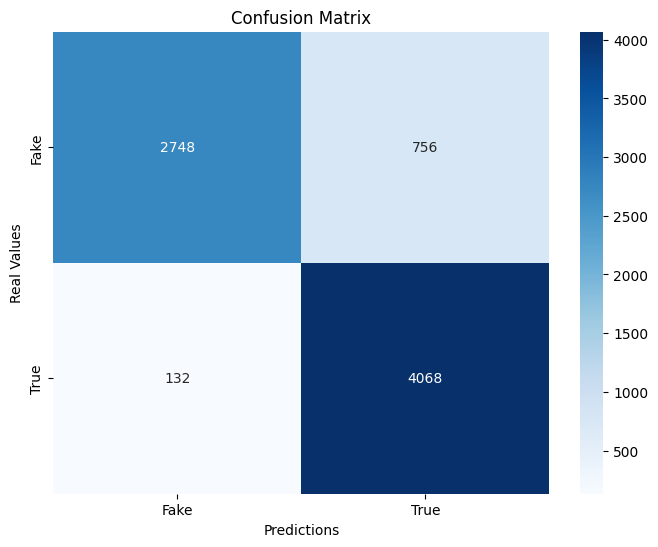

In [21]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Calcular a matriz de confusão
conf_matrix = confusion_matrix(y_test, y_pred_classes)

# Criar o heatmap da matriz de confusão
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues",
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel("Predictions")
plt.ylabel("Real Values")
plt.title("Confusion Matrix")
plt.show()

**LIME**

In [22]:
from lime.lime_text import LimeTextExplainer

explainer = LimeTextExplainer(class_names=le.classes_)

def predict_proba(texts):
    X = tfidf.transform(texts)          # mantém esparso
    return model.predict_proba(X)

idx = int(input(f"Digite o número da linha (0 a {len(X_test)-1}): "))
sample_text = X_test.iloc[idx]
sample_label = y_test.iloc[idx]

sample_tfidf = tfidf.transform([sample_text])   # sem .toarray()

pred_probs = model.predict_proba(sample_tfidf)
pred_class_idx = pred_probs.argmax(axis=1)[0]
pred_class_name = le.classes_[pred_class_idx]

print(f"Número da linha no X_test: {idx}")
print(f"Original text:\n{sample_text}")
print(f"Classe real: {le.classes_[sample_label]}")
print(f"Classe predita: {pred_class_name}")

explanation = explainer.explain_instance(
    sample_text,
    predict_proba,
    num_features=10
)

print(explanation.as_list())

Número da linha no X_test: 499
Original text:
party motherland north korea kim herald missile test setback
Classe real: True
Classe predita: True
[(np.str_('korea'), 0.06942069375595694), (np.str_('north'), 0.06531304523948529), (np.str_('kim'), -0.0018398218643183599), (np.str_('setback'), -0.0017252582944812637), (np.str_('test'), -0.0017130826230062001), (np.str_('missile'), -0.0015385999028497688), (np.str_('party'), 0.0007611835337669993), (np.str_('herald'), 0.0006574408239151652), (np.str_('motherland'), 0.00030080386036815274)]


In [23]:
# Obtém as palavras mais importantes e seus pesos
lime_features = explanation.as_list()

# Exibe cada palavra com seu impacto na predição
print("Palavras mais importantes e seus pesos:")
for word, weight in lime_features:
    print(f"{word}: {weight:.4f}")

Palavras mais importantes e seus pesos:
korea: 0.0694
north: 0.0653
kim: -0.0018
setback: -0.0017
test: -0.0017
missile: -0.0015
party: 0.0008
herald: 0.0007
motherland: 0.0003


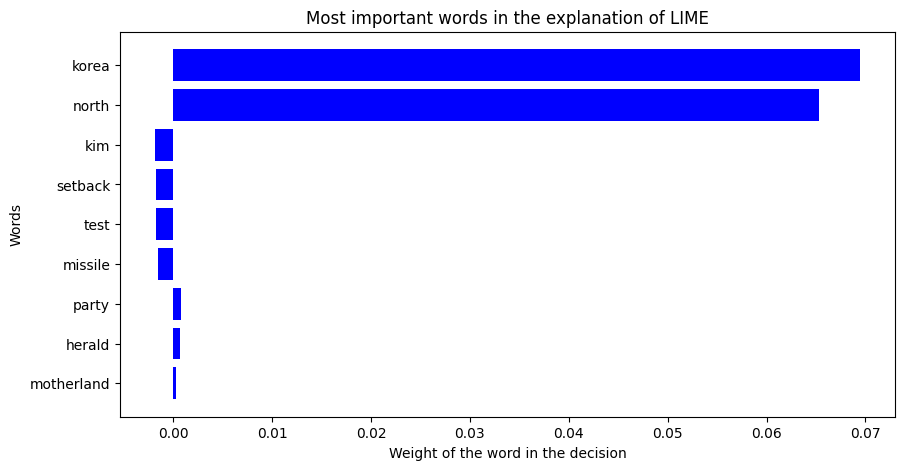

In [24]:
# Separar palavras e pesos
words, weights = zip(*lime_features)

# Criar gráfico de barras
plt.figure(figsize=(10, 5))
plt.barh(words, weights, color="blue")
plt.xlabel("Weight of the word in the decision")
plt.ylabel("Words")
plt.title("Most important words in the explanation of LIME")
plt.gca().invert_yaxis()  # Inverter para mostrar a palavra mais importante no topo
plt.show()

In [25]:
# Obter as palavras mais importantes e seus pesos no geral
words_weights = explanation.as_list()

# Imprimir as palavras e pesos
for word, weight in words_weights:
    print(f"{word}: {weight}")

korea: 0.06942069375595694
north: 0.06531304523948529
kim: -0.0018398218643183599
setback: -0.0017252582944812637
test: -0.0017130826230062001
missile: -0.0015385999028497688
party: 0.0007611835337669993
herald: 0.0006574408239151652
motherland: 0.00030080386036815274


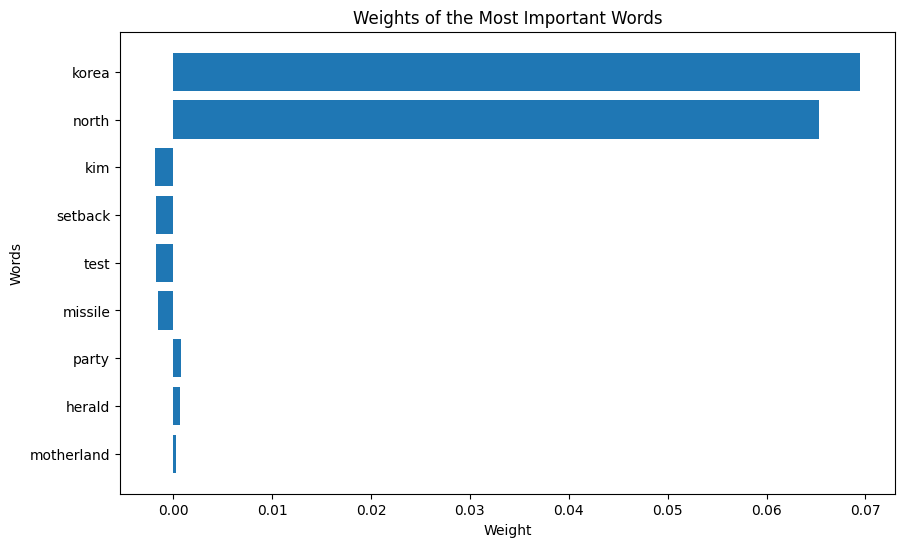

In [26]:
# Obter as palavras mais importantes e seus pesos no geral
words_weights = explanation.as_list()

# Separar palavras e pesos em listas separadas
words = [word for word, weight in words_weights]
weights = [weight for word, weight in words_weights]

# Criar o gráfico de barras horizontais
plt.figure(figsize=(10, 6))  # Ajustar o tamanho da figura, se necessário
plt.barh(words, weights)
plt.xlabel("Weight")
plt.ylabel("Words")
plt.title("Weights of the Most Important Words")
plt.gca().invert_yaxis()  # Inverter o eixo y para que as palavras mais importantes estejam no topo
plt.show()

**Attention Viz**

In [27]:
print(model)
print("Nº de árvores:", model.get_booster().num_boosted_rounds())
print("Nº de features:", model.n_features_in_)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type='gain',
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=-1,
              num_parallel_tree=None, ...)
Nº de árvores: 200
Nº de features: 5000


Texto usado na explicação:
party motherland north korea kim herald missile test setback

Classe prevista: 1
Probabilidades: [0.11886829 0.8811317 ]
Importance: (5000,)
Número de palavras: 7
   Feature     TFIDF    Weight  Contribution
1    korea  0.289278  0.006432      0.001861
3    north  0.280306  0.002694      0.000755
0      kim  0.444399  0.000076      0.000034
4    party  0.308105  0.000090      0.000028
2  missile  0.375398  0.000000      0.000000
5  setback  0.503664  0.000000      0.000000
6     test  0.388235  0.000000      0.000000


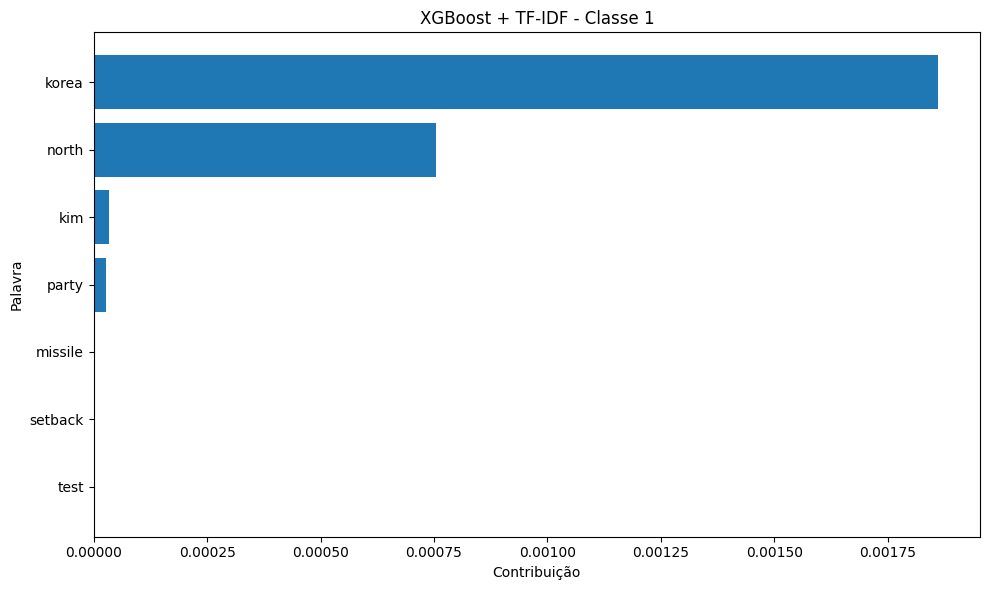

In [28]:
lime_idx = 499

sample_text = X_test.iloc[lime_idx]
print("Texto usado na explicação:")
print(sample_text)

# ETAPA 1: PREVISÃO
sample_tfidf = X_test_tfidf[lime_idx:lime_idx+1]
prediction = model.predict_proba(sample_tfidf)
predicted_class_index = np.argmax(prediction[0])

print(f"\nClasse prevista: {predicted_class_index}")
print("Probabilidades:", prediction[0])

# ETAPA 2: IMPORTÂNCIA GLOBAL DAS FEATURES (ganho médio dos splits)
feature_names = tfidf.get_feature_names_out()
global_importance = model.feature_importances_

print("Importance:", global_importance.shape)

# ETAPA 3: PALAVRAS PRESENTES NO TEXTO
tfidf_vector = sample_tfidf.toarray().flatten()
indices = np.where(tfidf_vector > 0)[0]
print("Número de palavras:", len(indices))

palavras = feature_names[indices]
pesos = global_importance[indices]
contribuicao = tfidf_vector[indices] * pesos

importancias = pd.DataFrame({
    "Feature": palavras,
    "TFIDF": tfidf_vector[indices],
    "Weight": pesos,
    "Contribution": contribuicao
}).sort_values(by="Contribution", ascending=False)

print(importancias.head(20))

# ETAPA 4: VISUALIZAÇÃO
top = importancias.head(20)

plt.figure(figsize=(10, 6))
plt.barh(top["Feature"], top["Contribution"])
plt.xlabel("Contribuição")
plt.ylabel("Palavra")
plt.title(f"XGBoost + TF-IDF - Classe {predicted_class_index}")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

Shapley

Classe prevista: 1
Palavras: ['korea' 'north' 'kim' 'party' 'test' 'setback' 'missile']
TF-IDF: [0.28927847 0.28030566 0.44439871 0.30810498 0.38823511 0.50366415
 0.3753981 ]
SHAP: [ 0.46259093  0.45278266 -0.04961656  0.00947662  0.          0.
  0.        ]


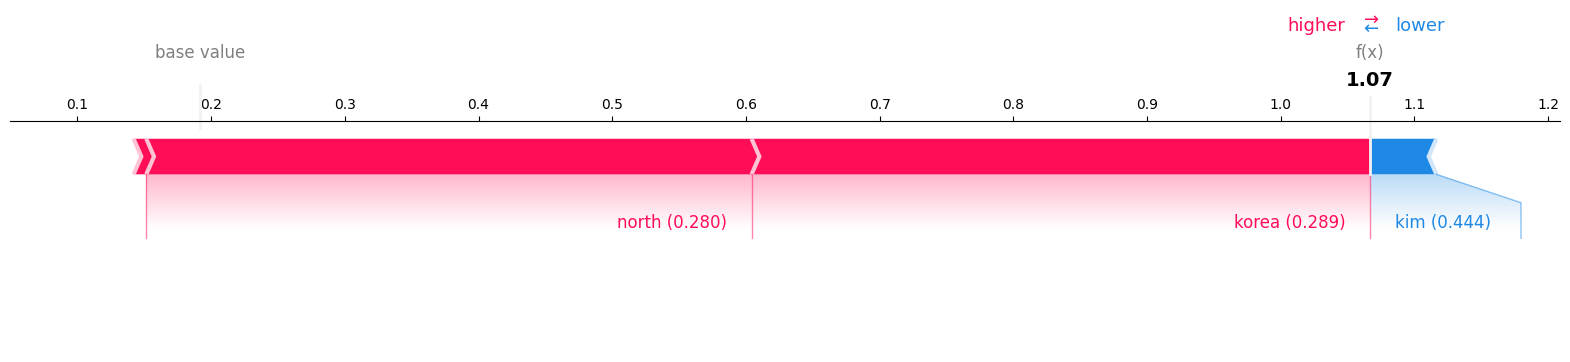

In [30]:
lime_idx = 499

X_instance = X_test_tfidf[lime_idx:lime_idx+1]   # mantém esparso

# Classe prevista
pred_probs = model.predict_proba(X_instance)
pred_class_idx = np.argmax(pred_probs, axis=1)[0]
print("Classe prevista:", pred_class_idx)

# TreeExplainer
explainer = shap.TreeExplainer(model)
shap_values = np.array(explainer.shap_values(X_instance)).reshape(-1)

expected_value = explainer.expected_value
if isinstance(expected_value, (list, np.ndarray)):
    expected_value = float(np.array(expected_value).reshape(-1)[0])

# O SHAP do XGBoost binário explica a classe 1 (em log-odds).
# Se a classe prevista for 0, inverte o sinal para explicar a classe prevista.
if pred_class_idx == 0:
    shap_values = -shap_values
    expected_value = -expected_value

# Palavras presentes no documento
feature_names = np.array(tfidf.get_feature_names_out())
tfidf_vector = X_instance.toarray().reshape(-1)
indices = np.where(tfidf_vector > 0)[0]

words = feature_names[indices]
values = shap_values[indices]
tfidf_values = tfidf_vector[indices]

# Ordenar por impacto absoluto
top_k = 15
order = np.argsort(np.abs(values))[::-1][:top_k]

words = words[order]
values = values[order]
tfidf_values = tfidf_values[order]

formatted_labels = [f"{w} ({t:.3f})" for w, t in zip(words, tfidf_values)]

print("Palavras:", words)
print("TF-IDF:", tfidf_values)
print("SHAP:", values)

shap.force_plot(
    base_value=expected_value,
    shap_values=values,
    #features=tfidf_values,
    feature_names=formatted_labels,
    matplotlib=True
)